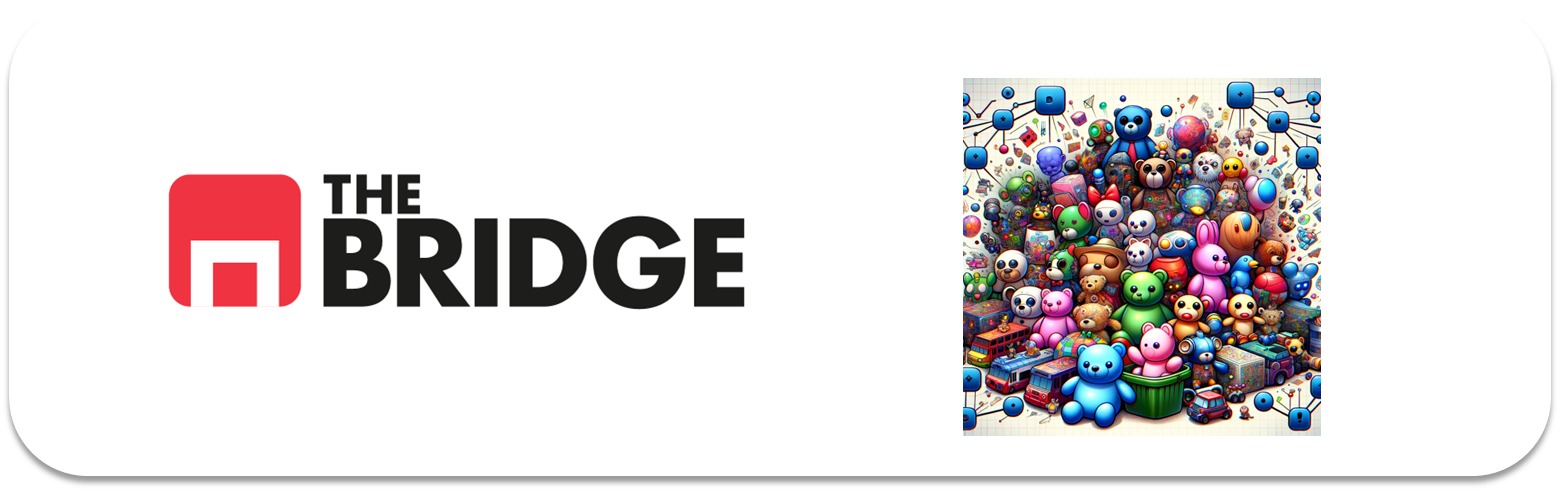

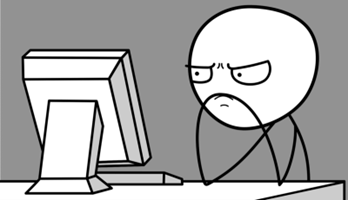

Para ejercitarte y afianzar lo aprendido sobre **K-Means**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Common imports
import numpy as np
import os
import pandas as pd
import toolbox_ML as tool

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

### Entendiendo el problema de negocio

En este notebook vamos a hacer un análisis de datos tirando de clusterizaciones para evaluar si existen grupos en nuestros productos, en este caso medicamentos, y posteriormente poder etiquetarlos. Poseemos información como rating, efectividad, efectos secundarios, entre otros.

### Ejercicio 1

Importa los datos, "./data/drugLibTrain_raw.tsv", que contiene un dataset con diferentes fármacos, sus efectos y ratings de los clientes de dichos fármacos. Realiza una inspección preliminar y quita las columnas que consideres innecesarias.

In [2]:
df= pd.read_csv("./data/drugLibTrain_raw.tsv", sep="\t")

df.head()


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


In [4]:
tool.describe_df(df)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
Unnamed: 0,numerica,0.0,3107,100.0
urlDrugName,categorica,0.0,502,16.16
rating,numerica,0.0,10,0.32
effectiveness,categorica,0.0,5,0.16
sideEffects,categorica,0.0,5,0.16
condition,categorica,0.0,1426,45.9
benefitsReview,categorica,0.6,3031,97.55
sideEffectsReview,categorica,2.4,2813,90.54
commentsReview,categorica,0.4,3046,98.04


### Ejercicio 2: MiniEDA

Como es un problema no supervisado (vamos a intentar agrupar los medicamentos sin tener una referencia o target inicial), no hay split, vamos directos al miniEDA. Analiza qué variables son descartables en función de su porcentaje de cardinalidad. Es decir obten la cardinalidad y su porcentaje para cada posible feature y crea un dataset nuevo descartando las features que creas conveniente. NOTA: Como simplificación, descarta la columna con url.

In [5]:
df= df.drop(columns= ["Unnamed: 0", "urlDrugName", "benefitsReview", "sideEffectsReview","commentsReview"], axis=1)

In [6]:
df.columns = df.columns.str.lower()
df.columns


Index(['rating', 'effectiveness', 'sideeffects', 'condition'], dtype='object')

In [7]:
tool.describe_df(df)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
rating,numerica,0.0,10,0.32
effectiveness,categorica,0.0,5,0.16
sideeffects,categorica,0.0,5,0.16
condition,categorica,0.0,1426,45.9


In [8]:
print(df.isna().sum())

rating           0
effectiveness    0
sideeffects      0
condition        1
dtype: int64


In [9]:
df.loc[df.condition.isna()]

,rating,effectiveness,sideeffects,condition
2488,2,Ineffective,No Side Effects,NaN


In [10]:
df.condition.value_counts()

condition
depression                    236
acne                          165
anxiety                        63
insomnia                       54
birth control                  49
                             ... 
sleep walking/talking           1
sore throat ear infections      1
nerve disorder                  1
skin cancer                     1
birth prevention                1
Name: count, Length: 1426, dtype: int64

In [11]:
df = df.dropna(subset=['condition'])

In [12]:
print(df.isna().sum())

rating           0
effectiveness    0
sideeffects      0
condition        0
dtype: int64


In [13]:
df = df.drop_duplicates()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2479 entries, 0 to 3105
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   rating         2479 non-null   int64 
 1   effectiveness  2479 non-null   object
 2   sideeffects    2479 non-null   object
 3   condition      2479 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [15]:
tool.describe_df(df)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
rating,numerica,0.0,10,0.4
effectiveness,categorica,0.0,5,0.2
sideeffects,categorica,0.0,5,0.2
condition,categorica,0.0,1426,57.52


In [16]:
df

,rating,effectiveness,sideeffects,condition
0,4,Highly Effective,Mild Side Effects,management of congestive heart failure
1,1,Highly Effective,Severe Side Effects,birth prevention
2,10,Highly Effective,No Side Effects,menstrual cramps
3,3,Marginally Effective,Mild Side Effects,acid reflux
4,2,Marginally Effective,Severe Side Effects,fibromyalgia
...,...,...,...,...
3097,8,Considerably Effective,No Side Effects,seasonal allergies
3098,10,Highly Effective,No Side Effects,"hives, itching, swelling due to allergies"
3101,8,Considerably Effective,No Side Effects,muscle relaxant - spinal disorder
3104,2,Marginally Effective,Moderate Side Effects,total hysterctomy


### Ejercicio 3

Construye un train set (llámalo X) sólo con las features que hayas seleccionado del ejercicio anterior (es decir las que no hayas descartado como posibles features) 

In [17]:
X = df

### Ejercicio 4 

Trasforma las features que consideres necesario (categóricas y numéricas) y luego aplica el escalado que consideres necesario.

In [18]:
X.columns

Index(['rating', 'effectiveness', 'sideeffects', 'condition'], dtype='object')

**Frequency Encoding** —> Reemplaza cada categoría por su frecuencia relativa en el dataset. Simple y no expande dimensiones.  
Con normalize=True se obtiene la frecuencia relativa (entre 0 y 1), lo cual es conveniente porque K-Means es sensible a la escala y así ya tiene la variable acotada. Aún así, es recomendable aplicar el StandardScaler junto al resto de variables numéricas para que todo esté en la misma escala antes del clustering.

In [19]:
frequency_map = X['condition'].value_counts(normalize=True)
X['condition_encoded'] = X['condition'].map(frequency_map)

In [20]:
X['condition_encoded'].value_counts()

condition_encoded
0.000403    1203
0.000807     174
0.001210     114
0.003227     104
0.006454      96
0.002017      85
0.001614      84
0.002420      84
0.026624      66
0.025817      64
0.004841      48
0.008471      42
0.007664      38
0.015329      38
0.006858      34
0.012908      32
0.011698      29
0.002824      28
0.010488      26
0.009278      23
0.004034      20
0.005647      14
0.005244      13
0.004437      11
0.003630       9
Name: count, dtype: int64

In [21]:
print(X['effectiveness'].value_counts())

effectiveness
Highly Effective          987
Considerably Effective    737
Moderately Effective      363
Ineffective               218
Marginally Effective      174
Name: count, dtype: int64


In [22]:
print(X['sideeffects'].value_counts())

sideeffects
Mild Side Effects                749
No Side Effects                  710
Moderate Side Effects            525
Severe Side Effects              335
Extremely Severe Side Effects    160
Name: count, dtype: int64


In [23]:
categorias_efectividad = ["Ineffective", "Marginally Effective", "Moderately Effective", "Considerably Effective", "Highly Effective"]
categorias_efecto_sec = [
    "No Side Effects",           # 0
    "Mild Side Effects",         # 1
    "Moderate Side Effects",     # 2
    "Severe Side Effects",       # 3
    "Extremely Severe Side Effects"  # 4
]
# ¿Qué pasaría en el orden inverso de 'sideeffects'?

from sklearn.preprocessing import OrdinalEncoder, StandardScaler

ordinal_encoder = OrdinalEncoder(categories=[categorias_efectividad, categorias_efecto_sec])
X[["effectiveness", "sideeffects"]] = ordinal_encoder.fit_transform(X[["effectiveness", "sideeffects"]])


In [24]:
X.columns

Index(['rating', 'effectiveness', 'sideeffects', 'condition',
       'condition_encoded'],
      dtype='object')

In [25]:
X = X.drop("condition", axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2479 entries, 0 to 3105
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             2479 non-null   int64  
 1   effectiveness      2479 non-null   float64
 2   sideeffects        2479 non-null   float64
 3   condition_encoded  2479 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 96.8 KB


In [26]:
features = ['rating', 'effectiveness', 'sideeffects', 'condition_encoded']
scaler = StandardScaler()
X_scaled =pd.DataFrame(scaler.fit_transform(X[features]), columns= features, index = X.index)


In [27]:
X_scaled.describe()

,rating,effectiveness,sideeffects,condition_encoded
count,2.479000e+03,2.479000e+03,2.479000e+03,2.479000e+03
mean,-6.878994e-17,4.585996e-17,9.422788e-17,-2.292998e-17
std,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00
min,-1.901640e+00,-2.255727e+00,-1.146602e+00,-5.149663e-01
25%,-5.694845e-01,-6.713814e-01,-1.146602e+00,-5.149663e-01
50%,4.296323e-01,1.207911e-01,-3.212750e-01,-4.502759e-01
75%,7.626712e-01,9.129637e-01,5.040521e-01,-6.213311e-02
max,1.095710e+00,9.129637e-01,2.154706e+00,3.689913e+00


### Ejercicio 5: Obtención de K, aproximación visual

Analiza la relación entre features (con scatter plots) una vez transformadas para comprobar si existe visualmente algún indicio del número de clústeres que podríamos estar buscando. Por otro lado este análisis nos puede hacer descartar alguna feature o generar una nueva

In [28]:
X.columns

Index(['rating', 'effectiveness', 'sideeffects', 'condition_encoded'], dtype='object')

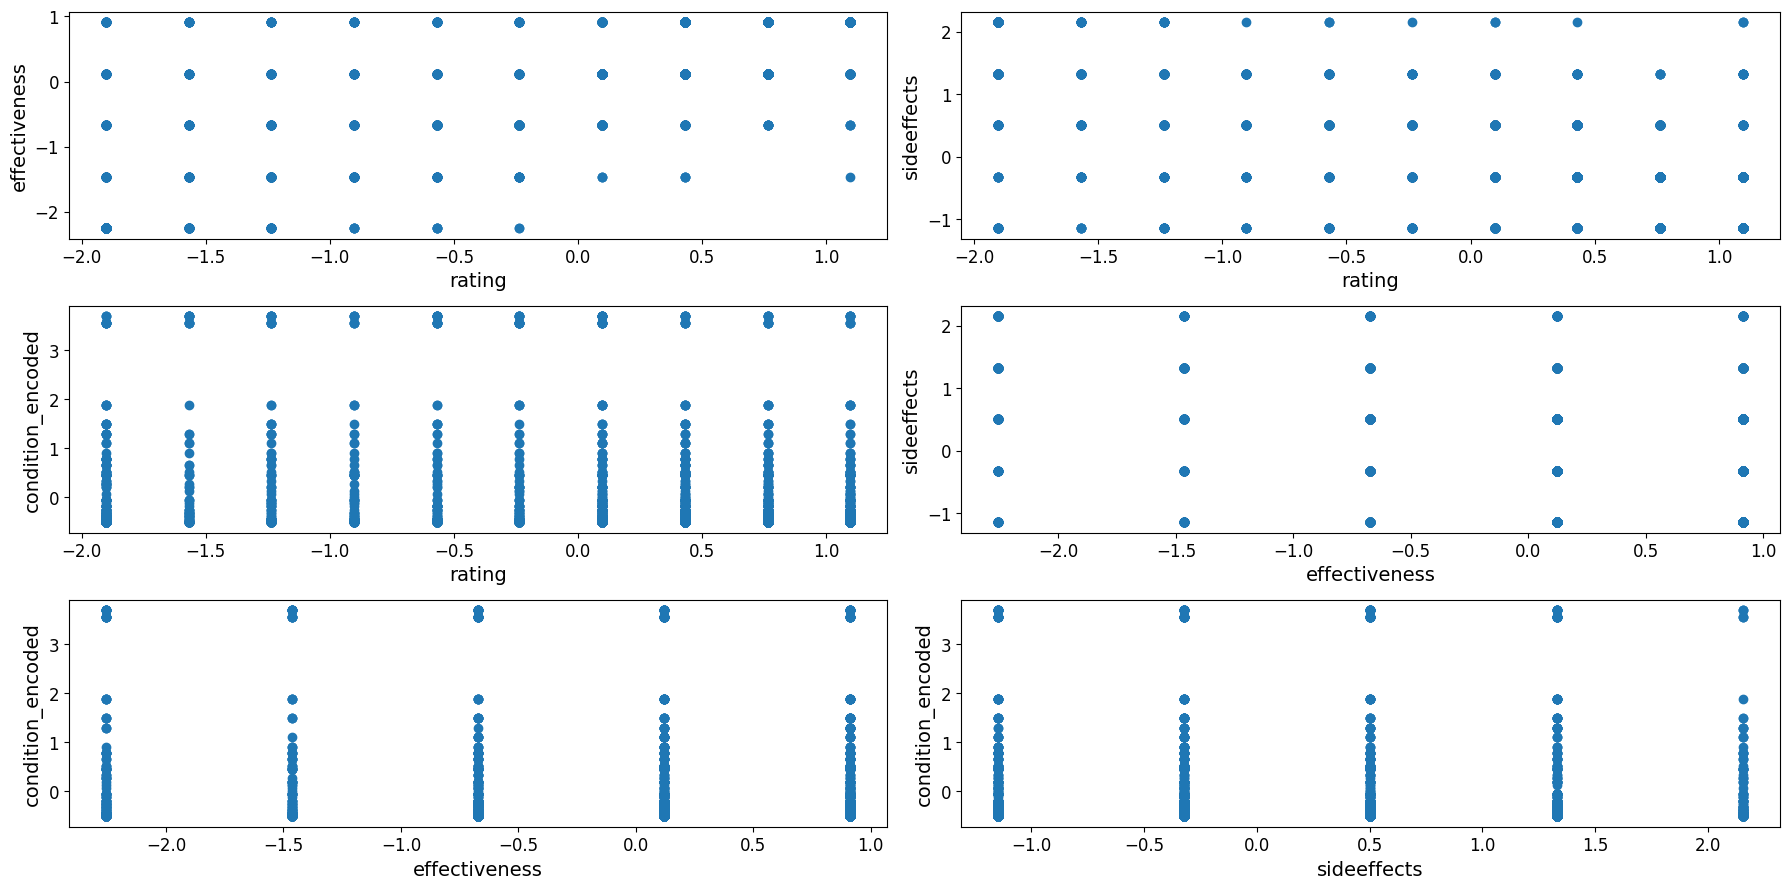

In [29]:
# ax[0,0] = plt.scatter(X_scaled.rating, X_scaled.effectiveness)
# Mal -> El código tiene un error conceptual importante. Estás haciendo ax[0,0] = plt.scatter(...)
#  lo cual sobreescribe el objeto eje con el resultado de scatter,
#  en lugar de dibujar sobre él. Lo correcto es llamar al scatter desde el propio eje: 

fig, ax = plt.subplots(3, 2, figsize=(18, 9))

ax[0,0].scatter(X_scaled.rating, X_scaled.effectiveness)
ax[0,0].set_xlabel('rating')
ax[0,0].set_ylabel('effectiveness')

ax[0,1].scatter(X_scaled.rating, X_scaled.sideeffects)
ax[0,1].set_xlabel('rating')
ax[0,1].set_ylabel('sideeffects')

ax[1,0].scatter(X_scaled.rating, X_scaled.condition_encoded)
ax[1,0].set_xlabel('rating')
ax[1,0].set_ylabel('condition_encoded')

ax[1,1].scatter(X_scaled.effectiveness, X_scaled.sideeffects)
ax[1,1].set_xlabel('effectiveness')
ax[1,1].set_ylabel('sideeffects')

ax[2,0].scatter(X_scaled.effectiveness, X_scaled.condition_encoded)
ax[2,0].set_xlabel('effectiveness')
ax[2,0].set_ylabel('condition_encoded')

ax[2,1].scatter(X_scaled.sideeffects, X_scaled.condition_encoded)
ax[2,1].set_xlabel('sideeffects')
ax[2,1].set_ylabel('condition_encoded')

plt.tight_layout()
plt.show()


Podía haber prescindido de condition_encoded, tiene la misma distribución con las otras tres variables.

### Ejercicio 6: Obtención de K, método del codo

Evalua diferentes valores K y escoge uno a partir del método del codo/elbow de inercia.

In [30]:
from sklearn.cluster import KMeans
kmeans_per_k = [KMeans(n_clusters=k, random_state= 42, n_init = 25).fit(X_scaled)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

In [31]:
inertias

[9916.000000000004,
 5885.705539227734,
 4223.510912320464,
 3444.1015647329737,
 2914.5851978746596,
 2521.5174117308597,
 2261.4521233154696,
 2063.0606906044095,
 1884.4569930135253]

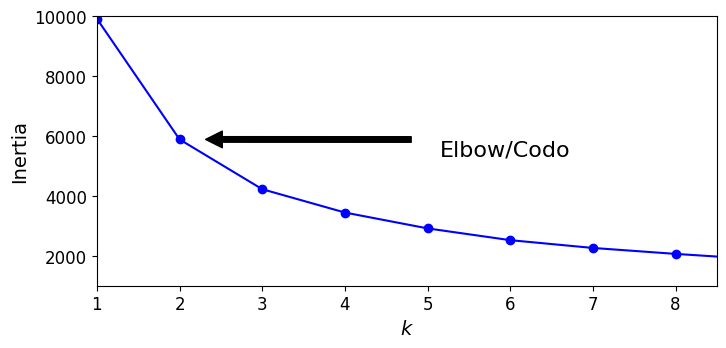

In [32]:
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow/Codo',
             xy=(2, inertias[1]),
             xytext=(0.55, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.axis([1, 8.5,1000, 10000])
plt.show()

### Ejercicio 7: Obtención de K, Score de Silueta

Comprueba el ajuste de k obteniendo el k que maximiza el score de silueta y pinta un gráfico de la evolución de dicho score con k. Usa los valores de k que hayas probado en el ejercicio anterior.

In [33]:
from sklearn.metrics import silhouette_score
silhouette_scores = [silhouette_score(X_scaled, model.labels_)
                     for model in kmeans_per_k[1:]]

In [34]:
silhouette_scores

[0.4332077615208385,
 0.46620976187511187,
 0.37151015932255527,
 0.37069441745048615,
 0.3557994943546593,
 0.3278399949228013,
 0.3354901370715178,
 0.33877021385822725]

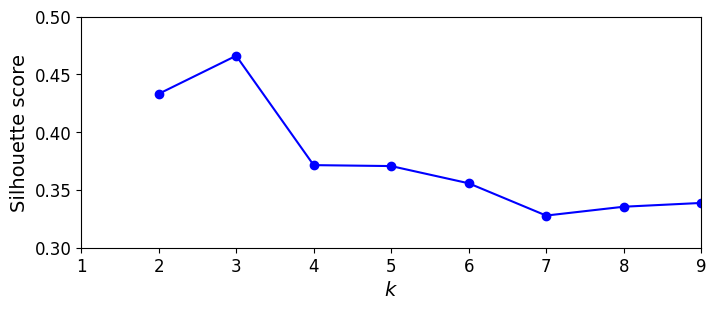

In [35]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.axis([1, 9, 0.30, 0.5])
plt.show()

### Ejercicio 8: Obtención de K, diagrama de silueta

Para completar el estudio de k, muestra el diagrama de silueta para k=2,3,4,5 y decide con este datos y los anteriores el valor de k a probar. NOTA: En la realidad, podríamos probar perfectamente k=2 y k=3 y luego que "Negocio" decidiera cuál le es más útil, aquí lo completamos por practicar todo lo aprendido.

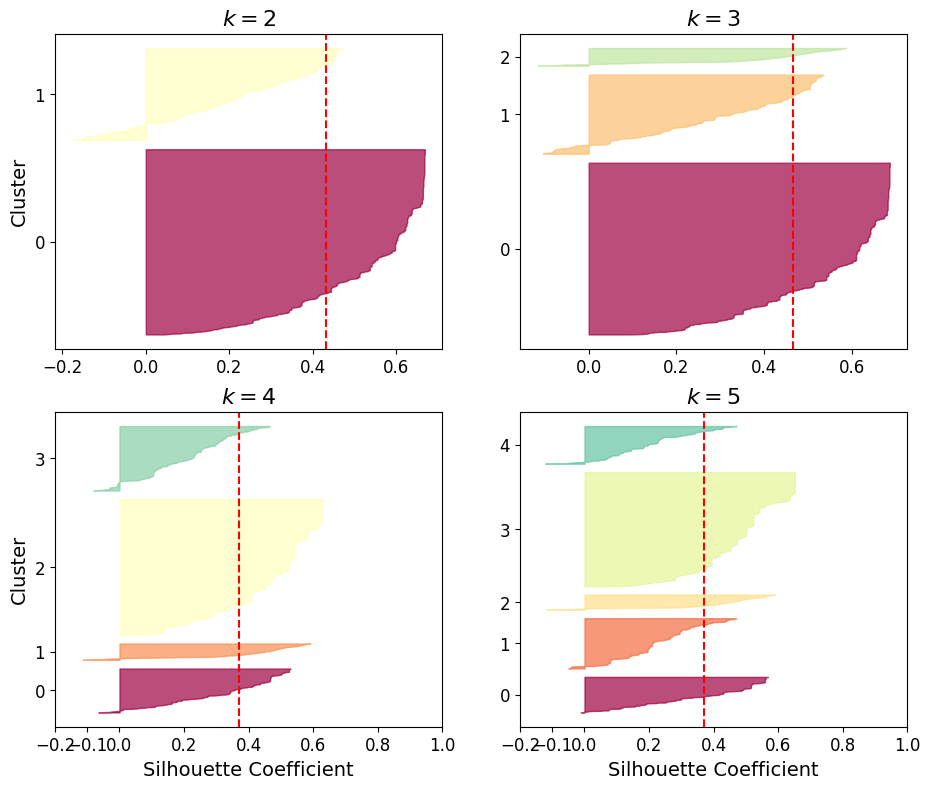

In [36]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)
    
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X_scaled, y_pred)

    padding = len(X_scaled) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (2, 4):
        plt.ylabel("Cluster")
    
    if k in (4, 5):
        plt.gca().set_xticks([-0.2, -0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=True)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)


plt.show()

### Ejercico 9:

En general, una diferencia entre el proceso de construcción de un modelo no supervisado y un supervisado es que el ajuste de algunos hiperparámetros (como el número de clústeres) es anterior a la construcción del modelo. Por eso, construye un K-means para el valor (o valores) de K escogidos.

El mejor k según las métricas: 3

In [37]:
kmeans = KMeans(n_clusters = 3,n_init="auto", random_state = 42)
kmeans.fit(X_scaled) 


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [38]:
y_pred = kmeans.predict(X_scaled)

In [39]:
print(y_pred)
print(y_pred == kmeans.labels_) #  is es True solo si ambas variables apuntan exactamente al mismo objeto en memoria, mientras que == compara el contenido.
print(kmeans.cluster_centers_)

[0 1 0 ... 0 1 0]
[ True  True  True ...  True  True  True]
[[ 0.60865385  0.48713972 -0.45874267 -0.25722484]
 [-1.25152993 -0.97305811  0.95402493 -0.17024593]
 [-0.31158237 -0.37673188  0.18700573  3.24378594]]


### Ejercicio 10

Vamos a comprobar resultados, analizando los valores medios y distribución de cada uno de los clústeres para el k óptimo. Si tuvieras más de un posible valor de k a probar, analiza aquí el de mayor score de silueta. Y utiliza el siguiente ejercicio para el otro. Además de hacer un describe de las features por clúster, pinta estos con un pairplot considerando sideEffects y rating como x e y (o viceversa) y el clúster como hue (color). Compara el resultado con los clústeres sugeridos en el ejercicio 5.

In [40]:
print(kmeans.inertia_)
print(kmeans.score(X_scaled))

4223.510912320464
-4223.510912320465


In [41]:
kmeans.feature_names_in_

array(['rating', 'effectiveness', 'sideeffects', 'condition_encoded'],
      dtype=object)

In [42]:
# Añadimos las estiquetas de label al DataFrame sin escalar, para que podamos interpretar las relaciones.
X_1 = X.copy()
X_1['cluster'] = y_pred

In [43]:
X_1.groupby('cluster')[features].mean()

,rating,effectiveness,sideeffects,condition_encoded
cluster,,,,
0,8.537539,3.462461,0.833438,0.002011
1,2.952055,1.619178,2.545205,0.002553
2,5.774390,2.371951,1.615854,0.023842


In [44]:
print(X_1.groupby('cluster')[features].describe().T)

cluster                            0           1           2
rating            count  1585.000000  730.000000  164.000000
                  mean      8.537539    2.952055    5.774390
                  std       1.327643    1.922833    2.617371
                  min       1.000000    1.000000    1.000000
                  25%       8.000000    1.000000    4.000000
                  50%       9.000000    3.000000    6.000000
                  75%      10.000000    4.750000    8.000000
                  max      10.000000   10.000000   10.000000
effectiveness     count  1585.000000  730.000000  164.000000
                  mean      3.462461    1.619178    2.371951
                  std       0.666674    1.307429    1.268570
                  min       1.000000    0.000000    0.000000
                  25%       3.000000    0.000000    2.000000
                  50%       4.000000    2.000000    3.000000
                  75%       4.000000    3.000000    3.000000
                  max   

Los clusters tienen perfiles muy claros e interpretables. Análisis:  
Cluster 0 — "Medicamentos excelentes" (747 pacientes)  
rating muy alto (media 8.9)
effectiveness alta (media 3.5 → "Considerably Effective")
sideeffects muy bajo (media 3.86 → "No Side Effects" / "Mild")
El grupo ideal: muy efectivos y sin apenas efectos secundarios

Cluster 1 — "Medicamentos problemáticos" (647 pacientes)  
rating muy bajo (media 2.5)
effectiveness baja (media 1.3 → "Marginally Effective")
sideeffects alto (media 1.6 → "Severe Side Effects")
El grupo peor: poco efectivos y con efectos secundarios severos

Cluster 2 — "Medicamentos intermedios" (1085 pacientes)  
rating medio-alto (media 7.7)
effectiveness media-alta (media 3.3)
sideeffects moderado (media 2.1 → "Moderate Side Effects")
El grupo más numeroso: efectivos pero con efectos secundarios moderados  

Sobre condition_encoded — Las medias son muy bajas y similares en los tres clusters (~0.002-0.006), lo que confirma lo que veíamos en los scatterplots: esta variable ha tenido poco peso real en la formación de los clusters.

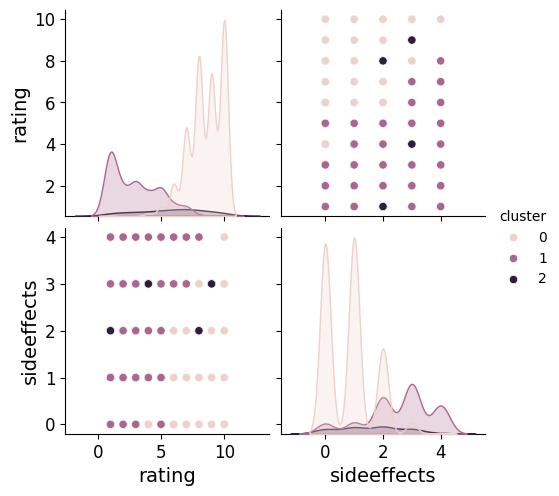

In [45]:
import seaborn as sns
sns.pairplot( X_1[['rating', 'sideeffects', 'cluster']], hue="cluster");

#La clave es pasar un DataFrame con todas las columnas que quieres visualizar,
#  incluyendo 'cluster' para que pueda colorear por grupo. 
# El parámetro hue hace referencia al nombre de una columna dentro de ese DataFrame, no a una Serie externa.

### Ejercicio 11, EXTRA: Más valores de K

Repite el análisis del ejercicio 10 para un K diferente pero que consideres que tiene sentido aplicar.

In [46]:
kmeans_2 = KMeans(n_clusters = 2,n_init="auto", random_state = 42)
kmeans_2.fit(X_scaled) 
y_pred_2 = kmeans_2.predict(X_scaled)
print(y_pred_2)
print(y_pred_2 == kmeans_2.labels_) #  is es True solo si ambas variables apuntan exactamente al mismo objeto en memoria, mientras que == compara el contenido.
print(kmeans_2.cluster_centers_)
print(kmeans_2.inertia_)
print(kmeans_2.score(X_scaled))

[0 1 0 ... 0 1 0]
[ True  True  True ...  True  True  True]
[[ 0.60128318  0.482175   -0.44893883 -0.11775518]
 [-1.20767434 -0.96844615  0.90169146  0.2365107 ]]
5885.717501950517
-5885.7175019505175


           rating  effectiveness  sideeffects  condition_encoded
cluster                                                         
0        8.515408       3.456193     0.845317           0.002880
1        3.083738       1.625000     2.481796           0.005089


cluster                            0           1
rating            count  1655.000000  824.000000
                  mean      8.515408    3.083738
                  std       1.337162    1.960491
                  min       1.000000    1.000000
                  25%       8.000000    1.000000
                  50%       9.000000    3.000000
                  75%      10.000000    5.000000
                  max      10.000000   10.000000
effectiveness     count  1655.000000  824.000000
                  mean      3.456193    1.625000
                  std       0.666423    1.290740
                  min       1.000000    0.000000
                  25%       3.000000    0.000000
                  50%       4.000000    2.000000
   

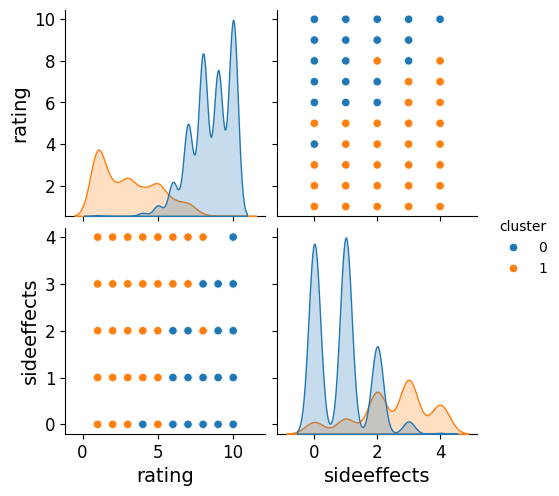

In [47]:
X_2 = X.copy()
X_2['cluster'] = y_pred_2
print(X_2.groupby('cluster')[features].mean())
print("\n")
print(X_2.groupby('cluster')[features].describe().T)
sns.pairplot( X_2[['rating', 'sideeffects', 'cluster']], hue="cluster");


Lo más relevante es que con k=2 los clusters 0 y 1 son prácticamente idénticos a los de k=3. La diferencia está en que k=3 añade un Cluster 2 intermedio que k=2 no es capaz de capturar, mezclando esos pacientes con los otros dos grupos.
Esto confirma definitivamente que k=3 es la mejor elección: no solo lo dicen las métricas, sino que también aporta información clínica adicional al separar un grupo intermedio que con k=2 queda diluido. Con k=2 estarías perdiendo matices importantes.